# Lab 03 — Chunking (interactive)

A guided, visual tour of Lab 03. It **imports the lab's own modules** (`chunkers`,
`questions`, `compare`, `shared.*`) — no logic is duplicated here, so this notebook
and `compare.py` can never drift.

**Before running:** open the tunnels in a terminal → `./tunnel.sh`
(this notebook talks to the same `rag_lab` Postgres.)


In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Find labs/ root (the folder containing shared/) and make imports work no matter
# where Jupyter started.
p = Path.cwd()
LABS = next(d for d in [p, *p.parents] if (d / "shared").exists())
for sub in (str(LABS), str(LABS / "03_chunking")):
    if sub not in sys.path:
        sys.path.insert(0, sub)
print("labs root:", LABS)


labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs


## Part 1 — Sentence segmentation: naive vs proper

The naive splitter breaks on *any* `.`/`!`/`?` + space, so it shatters
abbreviations like `Dr.`, `U.S.`, `e.g.`. A proper segmenter (**pysbd**; spaCy/nltk
do the same) keeps sentences whole. Watch what each does to a tricky document.


In [2]:
from chunkers import _sentences, _sentences_pysbd

text = (LABS / "03_chunking" / "corpus" / "instrument_manual.md").read_text()
print("TRICKY DOC:\n", text)

print("\nNAIVE splitter — note the broken fragments:")
for i, s in enumerate(_sentences(text), 1):
    print(f"  {i}. {s!r}")

print("\nPYSBD (proper) — sentences stay intact:")
for i, s in enumerate(_sentences_pysbd(text), 1):
    print(f"  {i}. {s!r}")


TRICKY DOC:
 The pressure sensor operates at 3.5 volts and must not exceed 5.0 volts. Dr. Ingrid Halvorsen, Ph.D., approved the design in the U.S. lab. Calibrate it approx. every 6 months, e.g. after any firmware update. The measured tolerance is 0.2 units.


NAIVE splitter — note the broken fragments:
  1. 'The pressure sensor operates at 3.5 volts and must not exceed 5.0 volts.'
  2. 'Dr.'
  3. 'Ingrid Halvorsen, Ph.D., approved the design in the U.S.'
  4. 'lab.'
  5. 'Calibrate it approx.'
  6. 'every 6 months, e.g.'
  7. 'after any firmware update.'
  8. 'The measured tolerance is 0.2 units.'

PYSBD (proper) — sentences stay intact:
  1. 'The pressure sensor operates at 3.5 volts and must not exceed 5.0 volts.'
  2. 'Dr. Ingrid Halvorsen, Ph.D., approved the design in the U.S. lab.'
  3. 'Calibrate it approx.'
  4. 'every 6 months, e.g. after any firmware update.'
  5. 'The measured tolerance is 0.2 units.'


Notice `'Dr.'` becomes its own 'sentence' under the naive splitter, so
`Dr. Ingrid Halvorsen` gets torn across a chunk boundary and can no longer be
retrieved as one phrase. That single failure is what the numbers below capture.


## Part 2 — Chunk the corpus every which way, then score it

`compare.build()` chunks the corpus with each strategy, embeds, and stores every
chunk. `compare.collect_metrics()` returns the hit@k / MRR numbers. Switch the
embedder to `"tei"` to run the embedding on the RTX 5090 (needs the :8085 tunnel).


In [3]:
from shared.embedder import get_embedder
import compare

emb = get_embedder("tei")   # or "tei" for the GPU service
compare.build(emb)
rows = compare.collect_metrics(emb)

# quick text table
print(f"{'strategy':<14}{'#chunks':>8}{'avg_words':>10}{'hit@1':>8}{'hit@3':>8}{'hit@5':>8}{'MRR':>7}")
for r in rows:
    print(f"{r['strategy']:<14}{r['n_chunks']:>8}{r['avg_words']:>10.1f}"
          f"{r['hit@1']:>8.2f}{r['hit@3']:>8.2f}{r['hit@5']:>8.2f}{r['mrr']:>7.2f}")


strategy       #chunks avg_words   hit@1   hit@3   hit@5    MRR
fixed-20/5          28      18.2    0.73    0.87    0.93   0.81
fixed-40/10         14      34.6    0.87    1.00    1.00   0.93
fixed-80/20          8      56.9    0.93    1.00    1.00   0.97
recursive-40        14      28.2    0.87    1.00    1.00   0.92
sentence-2          16      24.7    0.80    0.93    0.93   0.86
sentence-pysbd      15      26.3    0.87    1.00    1.00   0.92
semantic-0.5        18      21.9    0.73    0.80    0.87   0.78


## Part 3 — Visualise it

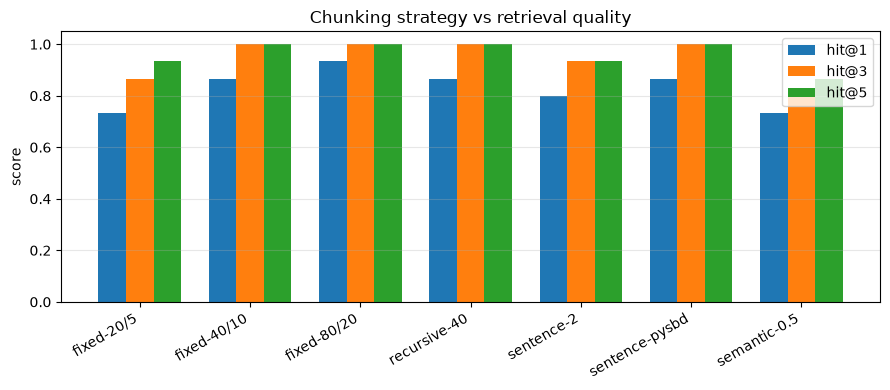

In [4]:
import numpy as np
import matplotlib.pyplot as plt

names = [r["strategy"] for r in rows]
x = np.arange(len(names))
w = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
for i, k in enumerate(["hit@1", "hit@3", "hit@5"]):
    ax.bar(x + (i - 1) * w, [r[k] for r in rows], w, label=k)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Chunking strategy vs retrieval quality")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


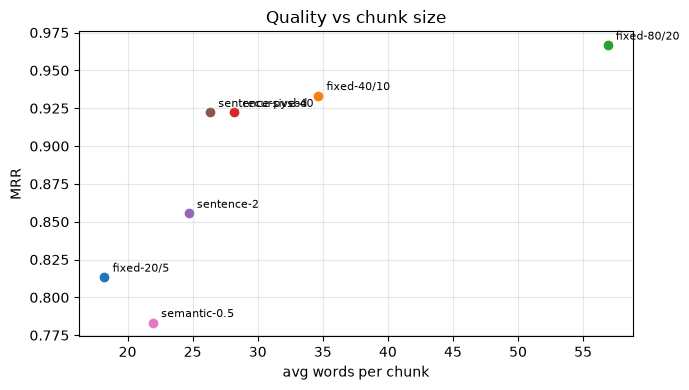

In [5]:
# Efficiency view: MRR against how many words each chunk stores on average.
# Up-and-left is better: high quality, fewer tokens per chunk.
fig, ax = plt.subplots(figsize=(7, 4))
for r in rows:
    ax.scatter(r["avg_words"], r["mrr"])
    ax.annotate(r["strategy"], (r["avg_words"], r["mrr"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("avg words per chunk")
ax.set_ylabel("MRR")
ax.set_title("Quality vs chunk size")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Try it yourself
- Re-run Part 2 with `get_embedder("tei")` — do the numbers change? (They shouldn't
  much: TEI serves the same MiniLM.)
- Edit `strategies()` in `compare.py` (e.g. `fixed(size=120)`) and re-run.
- Add a document with more abbreviations to `corpus/` and widen the naive-vs-pysbd gap.

Everything here calls the same code as `compare.py`, so anything you learn transfers
straight to the CLI lab.
